In [1]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

#### Parametros do setor 1 ######
data=np.loadtxt('par_setor27_2Min.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data[:,4]
print(len(ener))

37


/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
from altaipony.ffd import FFD, generate_random_power_law_distribution
simple_ffd = FFD(f=ener)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 16


No total observing time given. Set to 1. You are now working with number counts instead of frequency.


In [3]:
# a, b, g, size = energy lower and upper limit, power law exponent +1, number of flares
pwl = generate_random_power_law_distribution(np.min(ener), np.max(ener), -1, size=37, seed = 80)
#pwl= energy
# Create a FFD with the energies you detected. 
simple_ffd = FFD(f=pd.DataFrame({"ed_rec": pwl}))
simple_ffd.f.head()

No total observing time given. Set to 1. You are now working with number counts instead of frequency.


,ed_rec
0,3.330653e+32
1,5.250524e+32
2,2.192304e+32
3,4.857343e+32
4,1.628927e+33


In [4]:
simple_ffd
simple_ffd.tot_obs_time
ed, freq, counts = simple_ffd.ed_and_freq()

Setting ED with new values, size 37.
Setting frequency values with new values, size 37.
Setting frequency adjusted count values with new values, size 37.


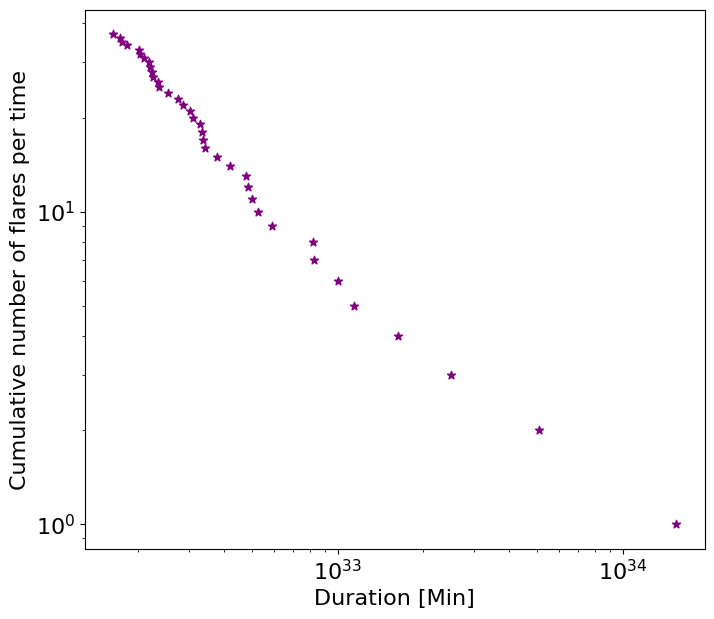

In [5]:
%matplotlib inline
plt.figure(figsize=(8, 7))
plt.scatter(ed, freq, c="purple", marker="*")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Duration [Min]")
plt.ylabel("Cumulative number of flares per time");
#plt.savefig('flares_duration.pdf', dpi=150, bbox_inches='tight', pad_inches=0.25)
#plt.text(180, 60, 'N=65', fontsize=18)

In [28]:
simple_ffd.fit_powerlaw("mcmc");
simple_ffd.alpha, simple_ffd.alpha_up_err, simple_ffd.alpha_low_err

/home/paola/.local/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/home/paola/anaconda3/lib/python3.9/site-packages/altaipony-2.0.1-py3.9.egg/altaipony/wheatland.py:313: RuntimeWarning: invalid value encountered in log
  f2 = M * np.log(alpha - 1)
100%|████████████████████████████████████████| 500/500 [00:03<00:00, 150.47it/s]


(2.0413708506976564, 0.18172089877089803, 0.1594662336215824)

In [29]:
simple_ffd.beta, simple_ffd.beta_up_err,  simple_ffd.beta_low_err,

(1.3801570190863702e+35, 1.1205629720244885e+41, 1.380148647064721e+35)

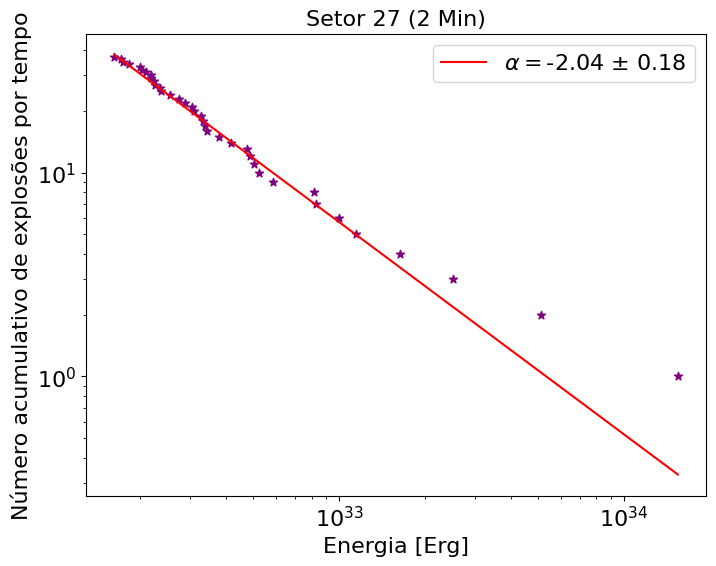

In [30]:
#Energia
%matplotlib inline
fig, ax = plt.subplots(1, figsize=(8,6))
ax.scatter(ed, freq, c="purple", marker="*")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energia [Erg]")
ax.set_ylabel("Número acumulativo de explosões por tempo")
plt.title('Setor 27 (2 Min)')
simple_ffd.plot_powerlaw(ax, c="r", label=fr'$\alpha=$-{simple_ffd.alpha:.2f} $\pm$ 0.18')
plt.savefig('fit_flares_energy.pdf', dpi=150, bbox_inches='tight', pad_inches=0.25)
#plt.text(3.5e34, 60, label='$\alpha', style="italic", fontsize=18)
plt.legend();